In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [2]:
df=pd.read_csv('Employee_Attrition.csv')
df.head()

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0


In [3]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [4]:
df=df.drop(columns=['Employee_ID'])

In [5]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,Age,Monthly_Income,Years_at_Company,Job_Satisfaction,Distance_From_Home,Attrition,Job_Role_Developer,Job_Role_HR,Job_Role_Manager,Work_Life_Balance_Good,Work_Life_Balance_Poor,Overtime_Yes,Education_Postgraduate,Education_School
0,29,23278,8,1,22,1,False,False,True,False,True,True,True,False
1,56,31395,18,1,7,1,False,True,False,False,True,True,False,True
2,54,98907,0,2,15,0,False,False,True,False,False,False,True,False
3,39,20851,5,2,7,0,False,True,False,True,False,False,False,False
4,28,32156,12,3,26,0,True,False,False,True,False,False,False,True


In [6]:
df.columns

Index(['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Attrition', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School'],
      dtype='object')

In [7]:
y=df['Attrition']
x=df[['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School']]

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((200, 13), (50, 13), (200,), (50,))

In [9]:
x=[]
MSE=[]
for i in range(1,26):
    nn=KNeighborsClassifier(n_neighbors=i)
    model=nn.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    cm=confusion_matrix(y_test,y_pred)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy=(TP+TN)/(TP+TN+FP+FN)
    x.append(accuracy)
    mse=mean_squared_error(y_test,y_pred)
    MSE.append(mse)
print(x)
Max=max(x)
print(Max)



[np.float64(0.86), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94), np.float64(0.94)]
0.94


In [10]:
x.index(0.94)

1

In [11]:
nn=KNeighborsClassifier(n_neighbors=2)
model=nn.fit(x_train,y_train)
y_pred=model.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
accuracy=(TP+TN)/(TP+TN+FP+FN)
ER=1-accuracy
SEN=TP/(TP+FN)
SPE=(TN)/(TN+FP)
print("Accuracy = ",accuracy)
print("Error Rate = ",ER)
print("Sensitivity = ",SEN)
print("Specificity = ",SPE)

Accuracy =  0.94
Error Rate =  0.06000000000000005
Sensitivity =  0.0
Specificity =  1.0


In [12]:
y1=model.predict([[30,450000,5,3,10,True,False,False,True,False,True,False,False]])
y1

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

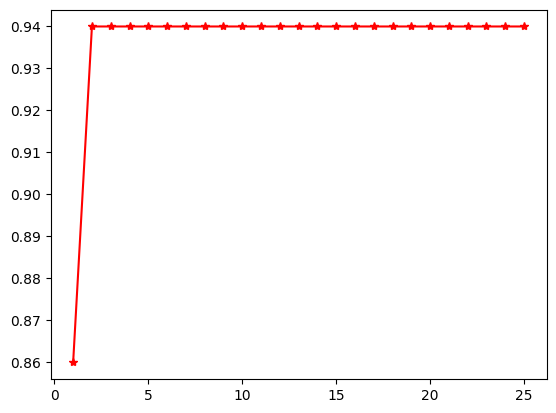

In [13]:
x1=list(range(1,26))
plt.plot(x1,x,'*-r')
plt.show()

In [14]:
# using randomforest

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

In [16]:
df=pd.read_csv('Employee_Attrition.csv')
df.head()

,Employee_ID,Age,Monthly_Income,Years_at_Company,Job_Role,Work_Life_Balance,Overtime,Job_Satisfaction,Distance_From_Home,Education,Attrition
0,1,29,23278,8,Manager,Poor,Yes,1,22,Postgraduate,1
1,2,56,31395,18,HR,Poor,Yes,1,7,School,1
2,3,54,98907,0,Manager,Excellent,No,2,15,Postgraduate,0
3,4,39,20851,5,HR,Good,No,2,7,Graduate,0
4,5,28,32156,12,Developer,Good,No,3,26,School,0


In [17]:
df.isna().sum()

Employee_ID           0
Age                   0
Monthly_Income        0
Years_at_Company      0
Job_Role              0
Work_Life_Balance     0
Overtime              0
Job_Satisfaction      0
Distance_From_Home    0
Education             0
Attrition             0
dtype: int64

In [18]:
df=df.drop(columns=['Employee_ID'])

In [19]:
df=pd.get_dummies(data=df,drop_first=True)
df.head()

,Age,Monthly_Income,Years_at_Company,Job_Satisfaction,Distance_From_Home,Attrition,Job_Role_Developer,Job_Role_HR,Job_Role_Manager,Work_Life_Balance_Good,Work_Life_Balance_Poor,Overtime_Yes,Education_Postgraduate,Education_School
0,29,23278,8,1,22,1,False,False,True,False,True,True,True,False
1,56,31395,18,1,7,1,False,True,False,False,True,True,False,True
2,54,98907,0,2,15,0,False,False,True,False,False,False,True,False
3,39,20851,5,2,7,0,False,True,False,True,False,False,False,False
4,28,32156,12,3,26,0,True,False,False,True,False,False,False,True


In [20]:
df.columns

Index(['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Attrition', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School'],
      dtype='object')

In [21]:
y=df['Attrition']
x=df[['Age', 'Monthly_Income', 'Years_at_Company', 'Job_Satisfaction',
       'Distance_From_Home', 'Job_Role_Developer', 'Job_Role_HR',
       'Job_Role_Manager', 'Work_Life_Balance_Good', 'Work_Life_Balance_Poor',
       'Overtime_Yes', 'Education_Postgraduate', 'Education_School']]

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((200, 13), (50, 13), (200,), (50,))

In [ ]:
rf=RandomForestClassifier(n_estimators=i,random_state=42,max_depth=5)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
cm=confusion_matrix(y_test,y_pred)
TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accuracy=(TP+TN)/(TP+TN+FP+FN)
    